## Project Overview
This notebook explores clustering of processed customer support tickets using different text representation methods. The goal is to identify meaningful groups of issues and compare the effectiveness of TF-IDF and sentence embedding approaches. 
The main pipelines implemented in this notebook:
- TF-IDF with K-Means clustering
- Sentence embeddings with K-Means clustering

In [1]:
# Necessary libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
from sklearn.metrics import silhouette_score
df = pd.read_csv("cleaned_data.csv")
print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [2]:
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'text', 'clean_text', 'processed_text']


In [3]:
# Vectorise cleaned text
tfidf = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.5, ngram_range=(1,2))

tfidf_matrix = tfidf.fit_transform(df['processed_text'].fillna(''))

### Text Vectorisation
The clean data was converted into numerical format using IF-IDF vectorisation. This allows for processing the text data by representing each document as a vector of features

In [4]:
#K-Means 
km_tfidf = KMeans(n_clusters=7, random_state=42)
df['cluster_tfidf'] = km_tfidf.fit_predict(tfidf_matrix)
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,text,clean_text,processed_text,cluster_tfidf
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,I'm having an issue with the {product_purchase...,having issue with the please assist\n\nyour...,billing zip code appreciate requested website ...,3
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,I'm having an issue with the {product_purchase...,having issue with the please assist\n\n you...,existing product intermittent unexpectedly,2
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,I'm facing a problem with my {product_purchase...,facing problem with the not turning wa...,turning yesterday respond really charger came ...,3
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,I'm having an issue with the {product_purchase...,having issue with the please assist\n\n you...,youre interested love see feedback unresolved,3
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,I'm having an issue with the {product_purchase...,having issue with the please assist\n\n\nno...,seller responsible damage arising delivery bat...,3


### K-Means clustering
KMean clustering was applied to group similar customer support tickets based on their textual content. This help identify underlying patterns and categories of customer issues.

In [5]:
print(df['cluster_tfidf'].value_counts())

cluster_tfidf
3    2838
0    1243
2    1002
1     985
6     739
4     691
5     579
Name: count, dtype: int64


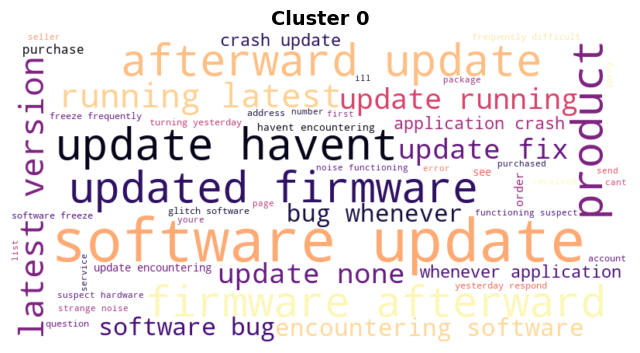

Cluster 0 - Top 10 words:
update:1340
software:957
product:393
updated:374
afterward:369
havent:369
firmware:363
version:222
fix:213
running:208



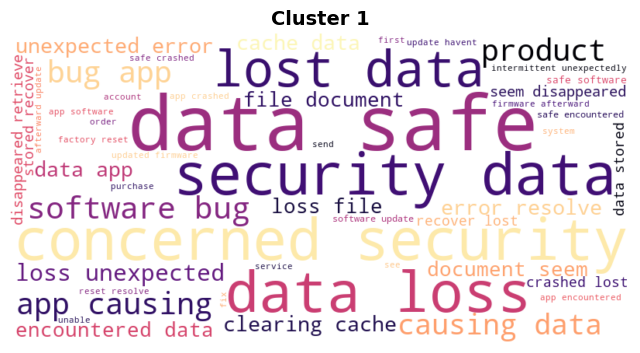

Cluster 1 - Top 10 words:
data:1253
app:411
safe:371
security:361
concerned:360
loss:350
lost:283
software:256
resolve:228
error:209



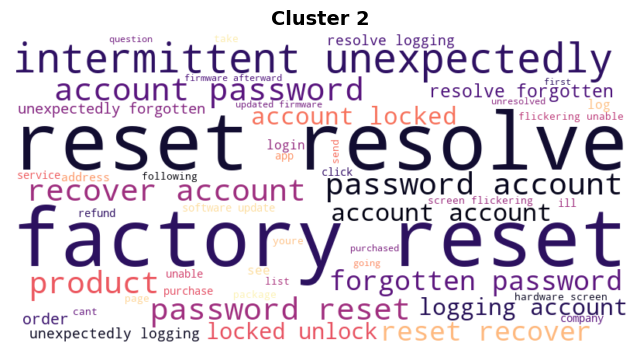

Cluster 2 - Top 10 words:
account:847
reset:585
password:448
resolve:393
factory:368
intermittent:347
unexpectedly:347
recover:218
product:189
forgotten:184



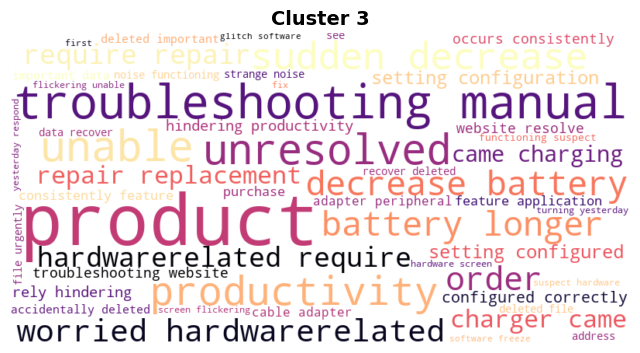

Cluster 3 - Top 10 words:
troubleshooting:471
product:438
productivity:438
unable:369
setting:353
manual:315
unresolved:259
deleted:244
longer:239
battery:219



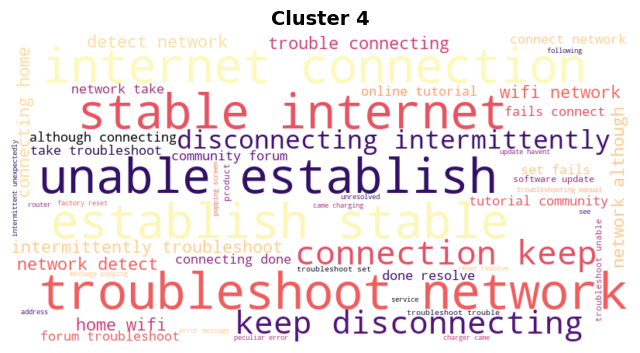

Cluster 4 - Top 10 words:
network:780
troubleshoot:542
connecting:362
resolve:235
unable:230
connection:206
internet:203
set:192
connect:192
stable:190



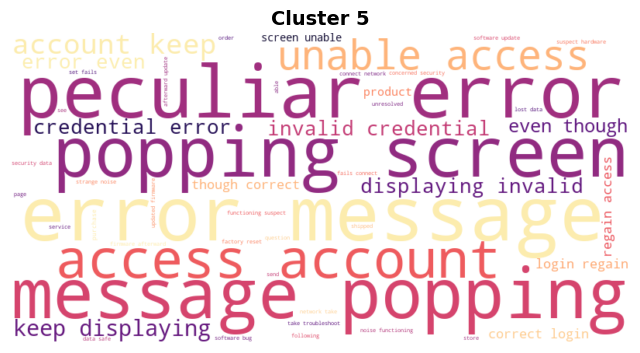

Cluster 5 - Top 10 words:
error:605
account:417
screen:415
message:411
peculiar:398
popping:398
access:369
unable:212
login:188
keep:186



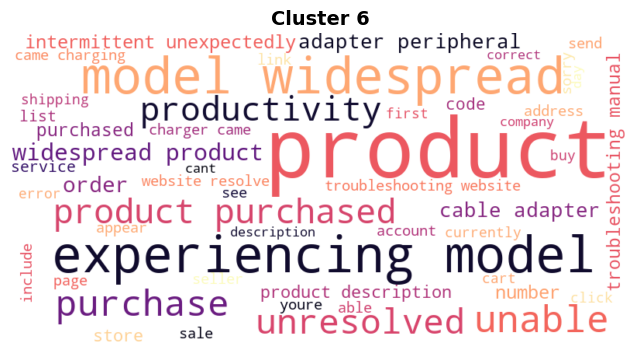

Cluster 6 - Top 10 words:
product:1066
experiencing:195
model:193
widespread:191
purchased:114
unable:93
productivity:90
purchase:86
unresolved:83
troubleshooting:56



In [6]:
# Wordclouds for each cluster
topic_mapping = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3",
    4: "Cluster 4",
    5: "Cluster 5",
    6: "Cluster 6",
}
df['topic_label'] = df['cluster_tfidf'].map(topic_mapping)
n_clusters = len(df['cluster_tfidf'].unique())
for i in range(n_clusters):
    cluster_text = " ".join(df[df['cluster_tfidf'] == i]['processed_text'].dropna().astype(str))
    #Split into words and count frequencies
    words = re.findall(r'\b[a-zA-Z]{3,}\b', cluster_text.lower()) 
    word_count = Counter(words)
    
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma', max_words=50).generate(" ".join(words))
    current_label = topic_mapping[i] 
    # Plot
    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"{current_label}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
        # Top 5 words
    top_words = word_count.most_common(10)
    print(f"Cluster {i} - Top 10 words:")
    for word, count in top_words:
        print(f"{word}:{count}")
    print()

Word clouds were generated for each cluster to visualise the most frequent terms, which will help in interpreting the underlying themes of each group.
## Cluster interpretation 
Some overlap is observed between clusters such as software and update as seen in clusters 0 and 3. This suggests that certain issues span multiple categories. 
### The connectivity/network & device setup issues
This cluster represents issues related to network connectivity and device configuration, where users appear to be experiencing network problems or difficulties setting up devices correctly. 
### Data security and loss concerns 
In the second cluster, most issues were security and data-related concerns raised by customers. 
### Account Access and Authentication Issues
for this cluster: top words where account, password reset, and access issues are mentioned, indicating that customers are having problems with authentication-related issues and application/device access. 
### General usage and productivity support
This cluster reflects general usage queries and productivity-related support, where some customers are requesting guidance on using applications/devices and improving workflows.

# TF-IDF

k=2, Silhouette score: 0.0196
k=3, Silhouette score: 0.0268
k=4, Silhouette score: 0.0349
k=5, Silhouette score: 0.0438
k=6, Silhouette score: 0.0504
k=7, Silhouette score: 0.0586
k=8, Silhouette score: 0.0634
k=9, Silhouette score: 0.0691
k=10, Silhouette score: 0.0787


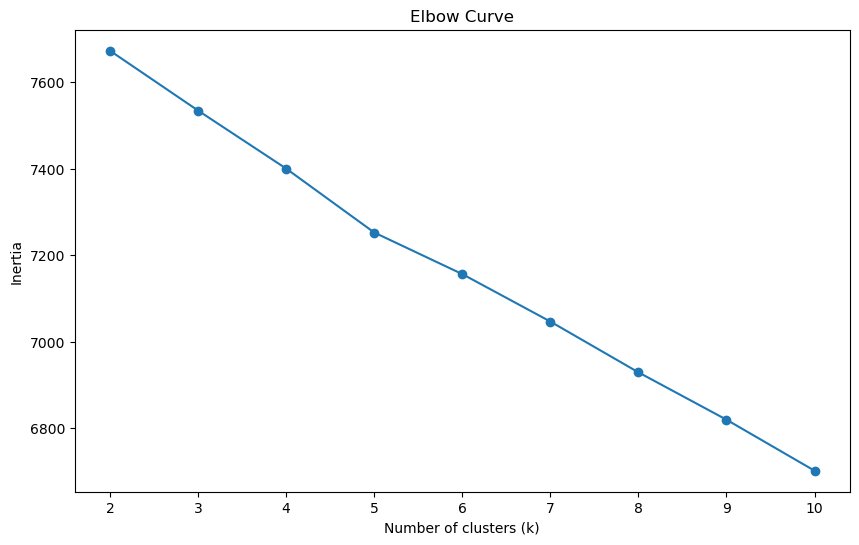

In [7]:
df['processed_text'] = df['processed_text'].fillna('')
tfidf_matrix = tfidf.fit_transform(df["processed_text"])
inertia = []
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tfidf_matrix)
    df['cluster_tfidf'] = labels
    # store inertia
    inertia.append (kmeans.inertia_)
    #silhouette score
    score = silhouette_score(tfidf_matrix, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette score: {score:.4f}")
# plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()


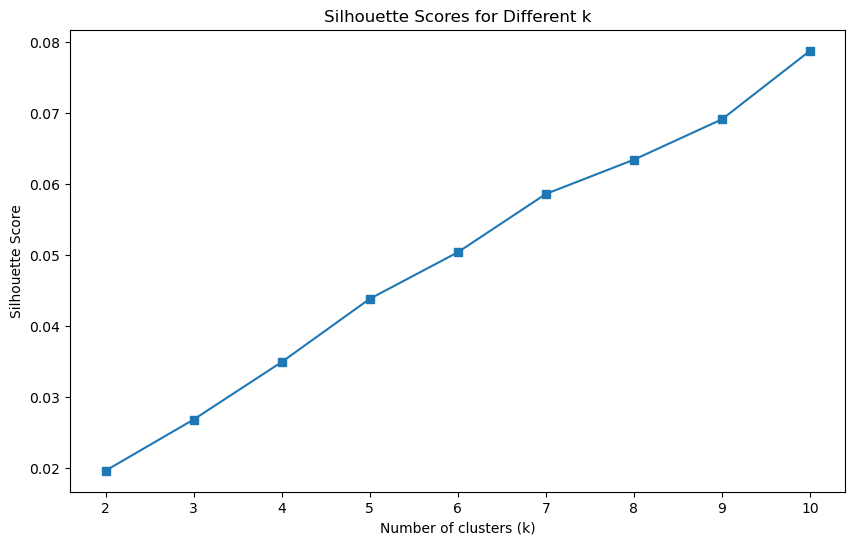

In [8]:

# plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='s')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k')
plt.show()

In [9]:
%pip install sentence-transformers
%pip install --upgrade datasets transformers sentence-transformers

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


# Sentence Embeddings

In [10]:
from sentence_transformers import SentenceTransformer

# Load the model
model = SentenceTransformer ('all-MiniLM-L6-v2')
embeddings = model.encode(df['processed_text'].fillna('').tolist())
km_embed = KMeans(n_clusters=7, random_state=42)
df['cluster_embed'] = km_embed.fit_predict(embeddings)
print(f"Loaded sentance-transformer model: '{model}'")

# Some example sentences for quality check

example_tickets = [
    "Password reset requested; I am locked out of my account.", # Account related
    "Login failed: system won't accept my sign-in details.",    # Account related
    "I've been double-billed for this month's plan.",           # Billing related
    "I need a PDF of my latest transaction receipt.",         #Billing related
    "Is it possible to include a CSV export option?"          # Requesting a new feature
]

# generate embeddings
example_embeddings = model.encode(example_tickets)
# check it works
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity([example_embeddings[0]], [example_embeddings[1]])
print(f"Test Similarity score for two accounts tickets: {sim[0][0]:.4f}")
sim = cosine_similarity([example_embeddings[0]], [example_embeddings[4]])
print(f"Test Similarity score for different tickets: {sim[0][0]:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded sentance-transformer model: 'SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)'
Test Similarity score for two accounts tickets: 0.5435
Test Similarity score for different tickets: -0.1041


In [11]:
# Process the dataset
df['embeddings'] = list(model.encode(df['processed_text'].astype(str), show_progress_bar=True))
# Save the dataframe
df.to_csv('embedded_customer_support_tickets.csv', index=False)

Batches:   0%|          | 0/253 [00:00<?, ?it/s]

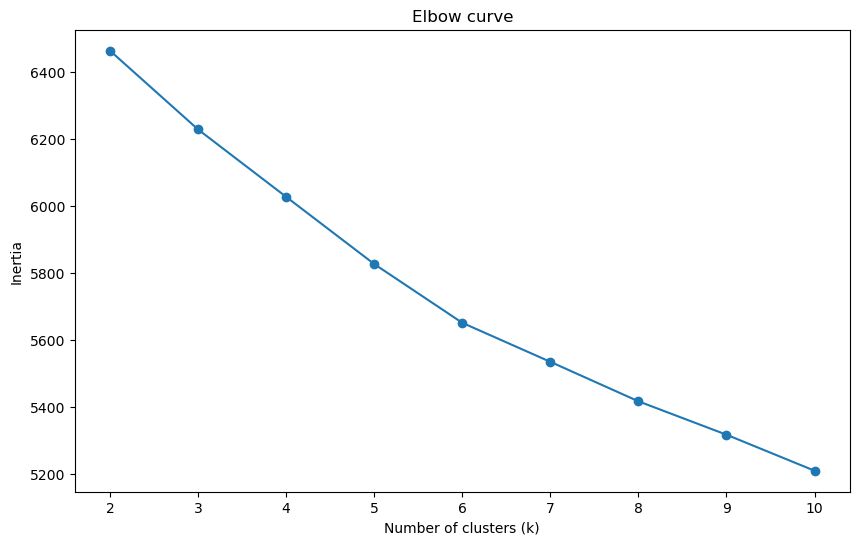

In [12]:
# convert the embedding list into 2D array for KMeans
x = np.stack(df['embeddings'].values)
# calculate inertia for K = 2 to 10
inertia = []
k_range = range(2 , 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    inertia.append(kmeans.inertia_)

# plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow curve')
plt.show()    

k=2 Silhouette score: 0.0431
k=3 Silhouette score: 0.0478
k=4 Silhouette score: 0.0525
k=5 Silhouette score: 0.0629
k=6 Silhouette score: 0.0687
k=7 Silhouette score: 0.0756
k=8 Silhouette score: 0.0757
k=9 Silhouette score: 0.0830
k=10 Silhouette score: 0.0910


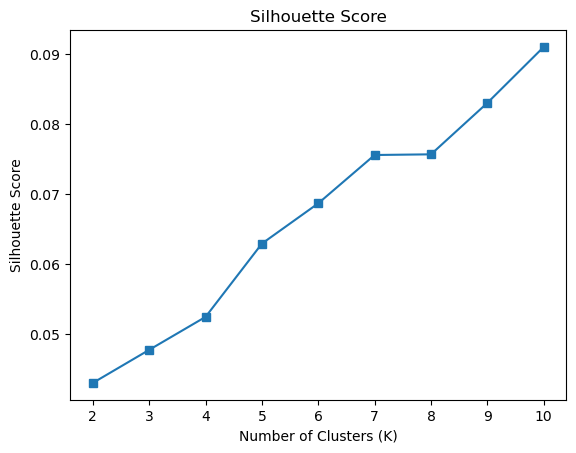

In [14]:
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    # Calculate the silhouette score
    score = silhouette_score(embeddings, cluster_labels)
    silhouette_scores.append(score)
    print(f"k={k} Silhouette score: {score:.4f}")
    inertia.append(kmeans.inertia_)

#plot
plt.plot(k_range, silhouette_scores, marker='s')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.show()